#### 4. División de Datos (Train / Test Split)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/credit_risk_dataset.csv')

# Separación de la variable objetivo de las características
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# División Train-Test
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,
    random_state=12345,
    stratify=y          # Para mantener la proporción de clases
)

print(f"Tamaño de Entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño de Prueba: {X_test.shape[0]} filas")

Tamaño de Entrenamiento: 26064 filas
Tamaño de Prueba: 6517 filas


#### 5. Limpieza de Datos y Feature Engineering

In [2]:
# Limpieza de Datos

# Información general de nulos en X_train
nulos_train = pd.DataFrame({
    'Nulos_Cantidad': X_train.isnull().sum(),
    'Nulos_Porcentaje %': (X_train.isnull().sum() / len(X_train)) * 100
})

# Filtrar solo las columnas que tienen al menos 1 nulo
nulos_train = nulos_train[nulos_train['Nulos_Cantidad'] > 0].sort_values(by='Nulos_Porcentaje %', ascending=False)
print(nulos_train)

                   Nulos_Cantidad  Nulos_Porcentaje %
loan_int_rate                2485            9.534223
person_emp_length             704            2.701044


Al ser porcentajes menores al 10%, la estrategia estándar y segura es la imputación.

In [3]:
# Calcular las medianas ÚNICAMENTE en X_train
mediana_emp_length = X_train['person_emp_length'].median()
mediana_int_rate = X_train['loan_int_rate'].median()

print(f"Mediana person_emp_length: {mediana_emp_length}")
print(f"Mediana loan_int_rate: {mediana_int_rate:.2f}%")

# Aplicar la imputación a X_train
X_train['person_emp_length'] = X_train['person_emp_length'].fillna(mediana_emp_length)
X_train['loan_int_rate'] = X_train['loan_int_rate'].fillna(mediana_int_rate)

# Aplicar la MISMA imputación a X_test (usando las medianas de Train)
X_test['person_emp_length'] = X_test['person_emp_length'].fillna(mediana_emp_length)
X_test['loan_int_rate'] = X_test['loan_int_rate'].fillna(mediana_int_rate)

print("\nNulos restantes en X_train:", X_train.isnull().sum().sum())
print("Nulos restantes en X_test:", X_test.isnull().sum().sum())

Mediana person_emp_length: 4.0
Mediana loan_int_rate: 10.99%

Nulos restantes en X_train: 0
Nulos restantes en X_test: 0


In [4]:
# Inspección de valores extremos (mínimos y máximos) en X_train
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

summary_stats = X_train[num_cols].describe().T[['min', 'mean', '50%', 'max']]
print("### Resumen estadístico de variables numéricas (X_train) ###")
print(summary_stats)

### Resumen estadístico de variables numéricas (X_train) ###
                                min          mean       50%         max
person_age                    20.00     27.709484     26.00      144.00
person_income               4000.00  66467.752225  55000.00  6000000.00
person_emp_length              0.00      4.771677      4.00      123.00
loan_amnt                    500.00   9604.955110   8000.00    35000.00
loan_int_rate                  5.42     11.009093     10.99       23.22
loan_percent_income            0.00      0.170031      0.15        0.78
cb_person_cred_hist_length     2.00      5.790976      4.00       30.00


In [5]:
# Filtrado de errores lógicos (outliers)

# Identificamos índices a eliminar en X_train que superan límites biológicos
idx_para_eliminar = X_train[
    (X_train['person_age'] > 100) | 
    (X_train['person_emp_length'] > 60) |
    (X_train['person_emp_length'] > X_train['person_age'])
].index

# Eliminamos esas filas de X_train y de y_train
X_train = X_train.drop(index=idx_para_eliminar)
y_train = y_train.drop(index=idx_para_eliminar)

# Limpiamos también si existiera alguno en X_test
idx_test_eliminar = X_test[
    (X_test['person_age'] > 100) | 
    (X_test['person_emp_length'] > 60) |
    (X_test['person_emp_length'] > X_test['person_age'])
].index

X_test = X_test.drop(index=idx_test_eliminar)
y_test = y_test.drop(index=idx_test_eliminar)


# Capping

# Calculamos el percentil 99 del ingreso SOLAMENTE en X_train
p99_income = X_train['person_income'].quantile(0.99)

print(f"Límite superior (Percentil 99) para person_income: ${p99_income:,.2f}")

# Comprobar la asimetría (skewness) antes 
print(f"Asimetría de person_income: {X_train['person_income'].skew():.2f}")

# Aplicamos el tope (capping) tanto en X_train como en X_test
X_train['person_income'] = np.where(X_train['person_income'] > p99_income, p99_income, X_train['person_income'])
X_test['person_income'] = np.where(X_test['person_income'] > p99_income, p99_income, X_test['person_income'])

# Comprobar la asimetría (skewness) después - Si está entre -1 y 2, la asimetría estaría en niveles más razonables
print(f"Asimetría de person_income: {X_train['person_income'].skew():.2f}")

# Si no baja, entrenaremos el modelo con capping probando p95, p99)

Límite superior (Percentil 99) para person_income: $226,075.00
Asimetría de person_income: 10.11
Asimetría de person_income: 1.70


In [6]:
# Feature Engineering

# Creación de variables derivadas (Ratios)

def add_financial_ratios(df):
    df = df.copy()
    
    # 1. Ratio Estabilidad laboral respecto a la edad
    df['emp_to_age_ratio'] = df['person_emp_length'] / (df['person_age'] + 1)
    
    # 2. Ratio Historial crediticio respecto a la edad
    df['credit_to_age_ratio'] = df['cb_person_cred_hist_length'] / (df['person_age'] + 1)
    
    return df

# Aplicamos la función independientemente a X_train y X_test
X_train = add_financial_ratios(X_train)
X_test = add_financial_ratios(X_test)

print(f"Nuevas dimensiones de X_train: {X_train.shape}")
print("Nuevas columnas creadas: ['emp_to_age_ratio', 'credit_to_age_ratio']")

Nuevas dimensiones de X_train: (26058, 13)
Nuevas columnas creadas: ['emp_to_age_ratio', 'credit_to_age_ratio']


In [7]:
# Lista de variables candidatas a eliminar por redundancia/multicolinealidad

# Eliminamos ÚNICAMENTE la variable redundante del historial crediticio
cols_a_eliminar = ['cb_person_cred_hist_length']

# Aplicamos en DataFrames
X_train = X_train.drop(columns=cols_a_eliminar, errors='ignore')
X_test = X_test.drop(columns=cols_a_eliminar, errors='ignore')

print(f"Número final de características para el modelado: {X_train.shape[1]}")

Número final de características para el modelado: 12


Se conserva la variable 'loan_percent_income' a pesar de estar conectada a las variables 'loan_amount' y 'person_income' y poder presentar multicolinealidad. Esto debido al alto valor predictivo descubierto en el análisis exploratorio.

#### 6. Preprocesamiento para Machine Learning

In [8]:
# Encoding de variables categóricas

# 1. Mapeo Ordinal para loan_grade
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
X_train['loan_grade'] = X_train['loan_grade'].map(grade_map)
X_test['loan_grade'] = X_test['loan_grade'].map(grade_map)

# 2. Mapeo Binario para historial de default previo
default_map = {'N': 0, 'Y': 1}
X_train['cb_person_default_on_file'] = X_train['cb_person_default_on_file'].map(default_map)
X_test['cb_person_default_on_file'] = X_test['cb_person_default_on_file'].map(default_map)

# 3. One-Hot Encoding para categóricas nominales
nominal_cols = ['person_home_ownership', 'loan_intent']

# Aplicamos pd.get_dummies a X_train
X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True, dtype=int)

# Aplicamos pd.get_dummies a X_test y re-alineamos columnas para evitar disparidades
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True, dtype=int)

# Garantizar que X_test tenga exactamente las mismas columnas que X_train (mismo orden)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"Dimensiones finales tras Encoding - X_train: {X_train.shape}, X_test: {X_test.shape}")

Dimensiones finales tras Encoding - X_train: (26058, 18), X_test: (6516, 18)


In [9]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Escalado de variables (Dual-Dataset Architecture)

# 1. Identificamos variables numéricas continuas que requieren escalado
# Nota: Las variables binarias/one-hot ya están entre 0 y 1, pero escalarlas
# junto con las numéricas no afecta a la Regresión Logística.
cols_to_scale = X_train.columns.tolist()

# 2. Inicializar el escalador
scaler = StandardScaler()

# 3. Fit_transform en X_train y transform en X_test con los parámetros del fit de X_train
X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

# 4. Reconstruir los DataFrames para conservar nombres de columnas e índices
X_train_scaled = pd.DataFrame(
    X_train_scaled_array, 
    columns=cols_to_scale, 
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array, 
    columns=cols_to_scale, 
    index=X_test.index
)

print("Verificación de estructuras de datos")
print(f"X_train (para XGBoost / LightGBM) - Media de 'person_income': {X_train['person_income'].mean():,.2f}")
print(f"X_train_scaled (para Regresión Logística) - Media de 'person_income': {X_train_scaled['person_income'].mean():.4f} (debe ser ~0)")
print(f"X_train_scaled (para Regresión Logística) - Desviación Estándar: {X_train_scaled['person_income'].std():.4f} (debe ser ~1)")

Verificación de estructuras de datos
X_train (para XGBoost / LightGBM) - Media de 'person_income': 64,557.68
X_train_scaled (para Regresión Logística) - Media de 'person_income': 0.0000 (debe ser ~0)
X_train_scaled (para Regresión Logística) - Desviación Estándar: 1.0000 (debe ser ~1)


In [10]:
# Tratamiento del Desbalanceo: Cálculo de Pesos de Clase

# 1. Conteo exacto en y_train (datos reales de entrenamiento)
conteo_clases = y_train.value_counts()
casos_0 = conteo_clases[0]
casos_1 = conteo_clases[1]

# 2. Ratio de peso para XGBoost / LightGBM
ratio_desbalance = casos_0 / casos_1

print(f"Casos 0 (Buenos): {casos_0} | Casos 1 (Morosos): {casos_1}")
print(f"Ratio de ponderación para algoritmos (scale_pos_weight): {ratio_desbalance:.2f}")

Casos 0 (Buenos): 20373 | Casos 1 (Morosos): 5685
Ratio de ponderación para algoritmos (scale_pos_weight): 3.58


Para manejar el desbalance (78/22), no se usará resampling (SMOTE) para evitar distorsionar las probabilidades calibradas de mora (PD). En su lugar, se aplicarán pesos de costo penalizado mediante class_weight='balanced' en Regresión Logística y scale_pos_weight=3.58 en modelos de árboles.

#### 7. Modelado

In [11]:
# Modelado - Fase 1 (Benchmark Base)

from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import xgboost as xgb

# Instanciamos los modelos con penalización por desbalance

# Baseline: Regresión Logística (L2 por defecto, para datos escalados)
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000, 
    random_state=12345
)

# Modelo Avanzado 1: LightGBM (para datos originales)
lgbm_model = lgb.LGBMClassifier(
    scale_pos_weight=ratio_desbalance, 
    random_state=12345, 
    verbose=-1
)

# Modelo Avanzado 2: XGBoost (para datos originales)
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=ratio_desbalance, 
    eval_metric='logloss', 
    random_state=12345
)

# 3. Entrenamiento de algoritmos
lr_model.fit(X_train_scaled, y_train)
lgbm_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

c:\Users\ADMIN\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ADMIN\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ADMIN\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ADMIN\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\ADMIN\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _wina

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


#### 8. Evaluación de Modelos (Métricas Bancarias)

In [12]:
# Evaluación de Modelos - Fase 1

import pandas as pd
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score

def calcular_metricas_bancarias(modelo, X_tr, y_tr, X_te, y_te, nombre_modelo):
    # Predicción de probabilidades para la clase 1 (Default)
    p_train = modelo.predict_proba(X_tr)[:, 1]
    p_test = modelo.predict_proba(X_te)[:, 1]
    
    # Métricas ROC-AUC
    auc_tr = roc_auc_score(y_tr, p_train)
    auc_te = roc_auc_score(y_te, p_test)
    
    # Coeficiente Gini (Gini = 2 * AUC - 1)
    gini_tr = 2 * auc_tr - 1
    gini_te = 2 * auc_te - 1
    
    # Estadístico KS (Kolmogorov-Smirnov)
    ks_stat, _ = ks_2samp(p_test[y_te == 1], p_test[y_te == 0])
    
    return {
        "Modelo": nombre_modelo,
        "AUC Train": round(auc_tr, 4),
        "AUC Test": round(auc_te, 4),
        "Gini Train": round(gini_tr, 4),
        "Gini Test": round(gini_te, 4),
        "KS Test (%)": round(ks_stat * 100, 2)
    }

# Consolidación del cuadro comparativo
resultados_fase1 = [
    calcular_metricas_bancarias(lr_model, X_train_scaled, y_train, X_test_scaled, y_test, "Regresión Logística"),
    calcular_metricas_bancarias(lgbm_model, X_train, y_train, X_test, y_test, "LightGBM"),
    calcular_metricas_bancarias(xgb_model, X_train, y_train, X_test, y_test, "XGBoost")
]

df_benchmark = pd.DataFrame(resultados_fase1)
print("### Resultados Fase 1: Benchmark Base ###")
print(df_benchmark.to_string(index=False))

### Resultados Fase 1: Benchmark Base ###
             Modelo  AUC Train  AUC Test  Gini Train  Gini Test  KS Test (%)
Regresión Logística     0.8652    0.8613      0.7304     0.7226        56.77
           LightGBM     0.9762    0.9470      0.9523     0.8940        75.96
            XGBoost     0.9936    0.9479      0.9872     0.8958        76.30


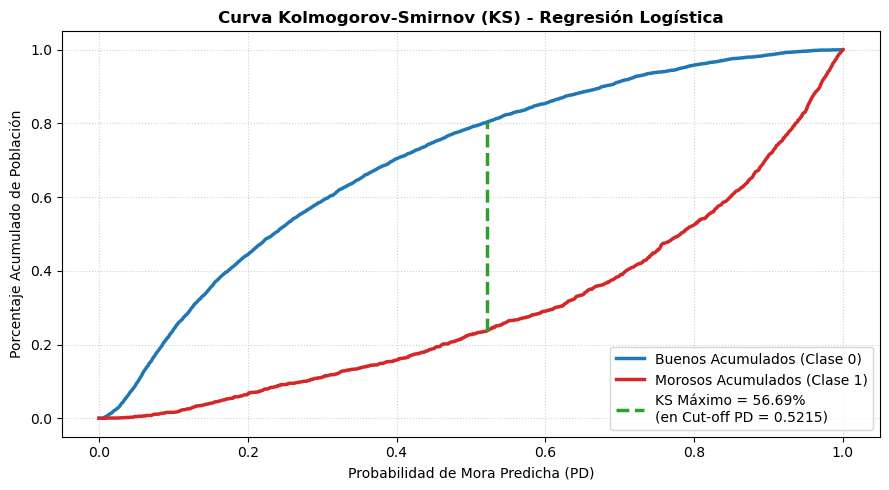

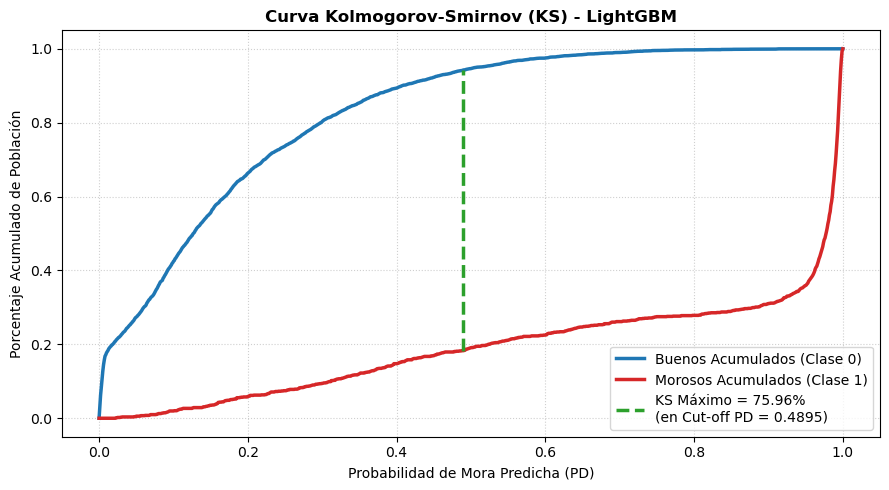

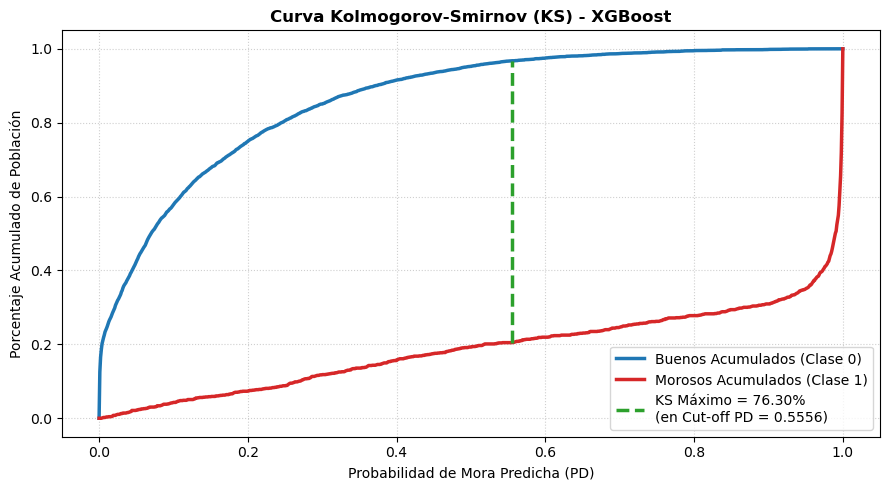

In [ ]:
# Visualización de Curvas Kolmogorov-Smirnov

import numpy as np
import matplotlib.pyplot as plt

def graficar_curva_ks(modelo, X_te, y_te, nombre_modelo):
    # 1. Obtenemos las probabilidades predichas de mora (clase 1)
    p_test = modelo.predict_proba(X_te)[:, 1]
    
    # 2. Separamos las probabilidades de buenos (0) y morosos (1)
    p_buenos = p_test[y_te == 0]
    p_malos = p_test[y_te == 1]
    
    # 3. Evaluamos la acumulación a lo largo de 1,000 umbrales de probabilidad
    umbrales = np.linspace(0, 1, 1000)
    acum_buenos = np.array([np.mean(p_buenos <= u) for u in umbrales])
    acum_malos = np.array([np.mean(p_malos <= u) for u in umbrales])
    
    # 4. Calculamos la distancia máxima (Estadístico KS)
    distancias = np.abs(acum_buenos - acum_malos)
    idx_ks = np.argmax(distancias)
    ks_val = distancias[idx_ks] * 100
    umbral_optimo = umbrales[idx_ks]
    
    # 5. Construcción de la gráfica
    plt.figure(figsize=(9, 5))
    
    # Curvas acumuladas
    plt.plot(umbrales, acum_buenos, label='Buenos Acumulados (Clase 0)', color='#1f77b4', lw=2.5)
    plt.plot(umbrales, acum_malos, label='Morosos Acumulados (Clase 1)', color='#d62728', lw=2.5)
    
    # Línea vertical del KS máximo
    plt.vlines(x=umbral_optimo, ymin=acum_malos[idx_ks], ymax=acum_buenos[idx_ks], 
               color='#2ca02c', linestyle='--', lw=2.5, 
               label=f'KS Máximo = {ks_val:.2f}%\n(en Cut-off PD = {umbral_optimo:.4f})')
    
    # Estilo y formato
    plt.title(f'Curva Kolmogorov-Smirnov (KS) - {nombre_modelo}', fontsize=12, fontweight='bold')
    plt.xlabel('Probabilidad de Mora Predicha (PD)', fontsize=10)
    plt.ylabel('Porcentaje Acumulado de Población', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right', frameon=True)
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------------
# EJECUCIÓN INDEPENDIENTE PARA CADA MODELO
# -------------------------------------------------------------------
graficar_curva_ks(lr_model, X_test_scaled, y_test, "Regresión Logística")
graficar_curva_ks(lgbm_model, X_test, y_test, "LightGBM")
graficar_curva_ks(xgb_model, X_test, y_test, "XGBoost")

La Regresión Logística no sufre de la misma propensión al sobreajuste (overfitting) que los modelos basados en árboles de decisión, por lo que un proceso de búsqueda exhaustiva de hiperparámetros es innecesario.

Solo se aplicarán estás técnicas a XGBoost y LightGBM

In [14]:
# Optimización y Regularización - Fase 2 (GridSearchCV + StratifieldKFold)

import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 1. Configuración de Validación Cruzada Estratificada (5 Folds)
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=12345)

# 2. Espacio de Búsqueda: LightGBM
param_grid_lgbm = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05],
    'min_child_samples': [30, 50],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'random_state': [12345]
}

# 3. Espacio de Búsqueda: XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4],
    'learning_rate': [0.01, 0.05],
    'min_child_weight': [5, 10],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'scale_pos_weight': [ratio_desbalance], # Mantiene la estrategia de imbalance
    'random_state': [12345]
}

print("Iniciando optimización de LightGBM...")
grid_lgbm = GridSearchCV(
    estimator=LGBMClassifier(class_weight='balanced', verbose=-1),
    param_grid=param_grid_lgbm,
    scoring='roc_auc',
    cv=cv_strat,
    n_jobs=-1
)
grid_lgbm.fit(X_train, y_train)

print("Iniciando optimización de XGBoost...")
grid_xgb = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss'),
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=cv_strat,
    n_jobs=-1
)
grid_xgb.fit(X_train, y_train)

# Modelos Tunearon y Listos
lgbm_opt = grid_lgbm.best_estimator_
xgb_opt = grid_xgb.best_estimator_

print("Mejores parámetros LightGBM:", grid_lgbm.best_params_)
print("Mejores parámetros XGBoost:", grid_xgb.best_params_)

Iniciando optimización de LightGBM...
Iniciando optimización de XGBoost...
Mejores parámetros LightGBM: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_samples': 30, 'n_estimators': 200, 'random_state': 12345, 'subsample': 0.8}
Mejores parámetros XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 200, 'random_state': 12345, 'scale_pos_weight': 3.583641160949868, 'subsample': 0.8}


In [15]:
# Comparación de métricas - Fase 2
resultados_fase2 = [
    calcular_metricas_bancarias(lr_model, X_train_scaled, y_train, X_test_scaled, y_test, "Regresión Logística (Base)"),
    calcular_metricas_bancarias(lgbm_opt, X_train, y_train, X_test, y_test, "LightGBM (Optimizada)"),
    calcular_metricas_bancarias(xgb_opt, X_train, y_train, X_test, y_test, "XGBoost (Optimizado)")
]

df_fase2 = pd.DataFrame(resultados_fase2)
print("\n### Resultados Fase 2: Modelos Regularizados ###")
print(df_fase2.to_string(index=False))


### Resultados Fase 2: Modelos Regularizados ###
                    Modelo  AUC Train  AUC Test  Gini Train  Gini Test  KS Test (%)
Regresión Logística (Base)     0.8652    0.8613      0.7304     0.7226        56.77
     LightGBM (Optimizada)     0.9567    0.9396      0.9135     0.8793        74.06
      XGBoost (Optimizado)     0.9474    0.9357      0.8949     0.8713        72.82


c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


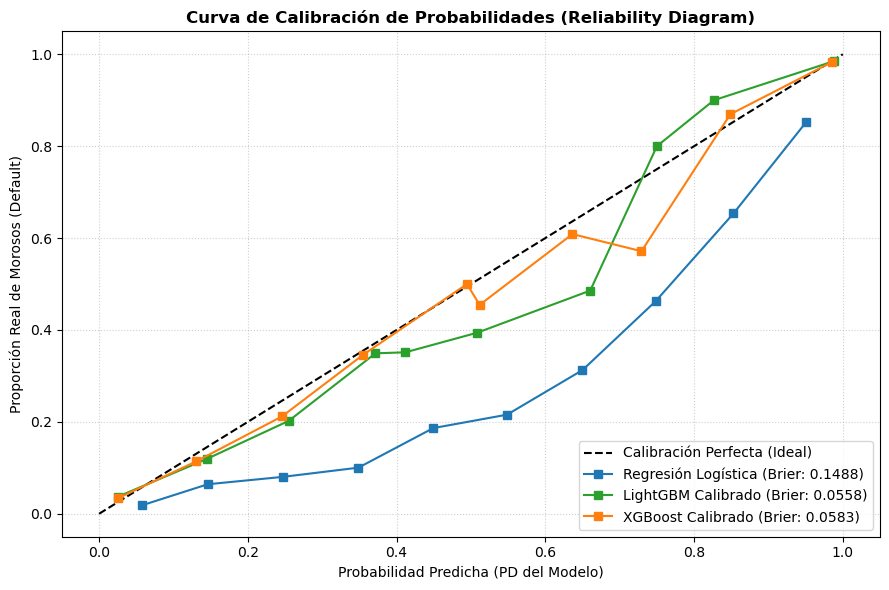

In [16]:
# Calibración de probabilidades con Isotonic Regression - Fase 3

import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

# ---------------------------------------------------------------------
# EXPLICACIÓN 1: Calibrar los modelos entrenados en la Fase 2
# Usa cv='prefit' porque los modelos lgbm_opt y xgb_opt YA están entrenados.
# ---------------------------------------------------------------------
lgbm_calibrado = CalibratedClassifierCV(lgbm_opt, method='isotonic', cv='prefit')
lgbm_calibrado.fit(X_train, y_train)

xgb_calibrado = CalibratedClassifierCV(xgb_opt, method='isotonic', cv='prefit')
xgb_calibrado.fit(X_train, y_train)

# ---------------------------------------------------------------------
# EXPLICACIÓN 2: Función para evaluar la Calibración Financiera
# Calcula el Brier Score (Error Cuadrático Medio de la probabilidad)
# y extrae los puntos para graficar la curva de confiabilidad.
# ---------------------------------------------------------------------
def evaluar_calibracion(modelo, X_te, y_te):
    # Extraemos la probabilidad predicha de la clase 1 (Default)
    p_test = modelo.predict_proba(X_te)[:, 1]
    
    # Brier Score: Medida de exactitud de la probabilidad (0.0 es perfecto)
    brier = brier_score_loss(y_te, p_test)
    
    # Divide la población en 10 deciles (bins) y calcula la mora real por decil
    prob_real, prob_predicha = calibration_curve(y_te, p_test, n_bins=10)
    
    return brier, prob_real, prob_predicha

# Evaluación de los 3 modelos (Regresión Logística, LightGBM y XGBoost)
brier_lr, real_lr, pred_lr = evaluar_calibracion(lr_model, X_test_scaled, y_test)
brier_lgbm, real_lgbm, pred_lgbm = evaluar_calibracion(lgbm_calibrado, X_test, y_test)
brier_xgb, real_xgb, pred_xgb = evaluar_calibracion(xgb_calibrado, X_test, y_test)

# ---------------------------------------------------------------------
# EXPLICACIÓN 3: Construcción de la Curva de Calibración (Reliability Diagram)
# Si los puntos caen sobre la línea diagonal de puntos, la calibración es perfecta.
# ---------------------------------------------------------------------
plt.figure(figsize=(9, 6))

# Línea de referencia: Calibración Perfecta (10% predicho = 10% mora real)
plt.plot([0, 1], [0, 1], "k--", label="Calibración Perfecta (Ideal)", lw=1.5)

# Curvas de nuestros modelos
plt.plot(pred_lr, real_lr, "s-", label=f"Regresión Logística (Brier: {brier_lr:.4f})", color='#1f77b4')
plt.plot(pred_lgbm, real_lgbm, "s-", label=f"LightGBM Calibrado (Brier: {brier_lgbm:.4f})", color='#2ca02c')
plt.plot(pred_xgb, real_xgb, "s-", label=f"XGBoost Calibrado (Brier: {brier_xgb:.4f})", color='#ff7f0e')

plt.ylabel("Proporción Real de Morosos (Default)", fontsize=10)
plt.xlabel("Probabilidad Predicha (PD del Modelo)", fontsize=10)
plt.title("Curva de Calibración de Probabilidades (Reliability Diagram)", fontsize=12, fontweight='bold')
plt.legend(loc="lower right", frameon=True)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

#### Jerarquía de Decisión Bancaria para la selección del modelo final

Esta se va a determinar entre los dos modelos de árboles calibrados, ya que ambos superan al modelo de Regresión Logística tras el análisis en el cálculo del Brier Score 

Pilar 1: Menor Overfitting ($\Delta\text{Gini} = \vert{}\text{Gini Train} - \text{Gini Test}\vert{}$)
- Ganador: XGBoost Calibrado, ya que presentó una brecha Train/Test de solo $2.36\%$ ($89.49\%$ vs $87.13\%$), frente a una brecha mayor en LightGBM ($91.35\%$ vs $87.93\%$).

Pilar 2: Poder de Separación ($KS$ Máximo en Test)
- Resultado: Ambos modelos entregan un $KS > 72\%$, superando ampliamente el estándar regulatorio mínimo del sector ($KS \ge 40\%$).

Pilar 3: Exactitud de la Probabilidad (Brier Score)
- Resultado: La diferencia entre $0.0558$ (LightGBM) y $0.0583$ (XGBoost) es insignificante en la práctica ($0.0025$), por lo que ambos satisfacen el requerimiento de calibración financiera para el cálculo de Pérdida Esperada ($\text{EL}$).

POLÍTICA DE CRÉDITO Y CUT-OFF ÓPTIMO (XGBOOST CALIBRADO)
Cut-off Óptimo (PD*): 0.2683 (26.83%)
Estadístico KS Máximo: 72.49%
------------------------------------------------------------
Tasa de Aprobación Estimada: 78.47% de la cartera
Tasa de Rechazo Estimada: 21.53% de la cartera
------------------------------------------------------------
Matriz de Confusión Operativa (Absoluta):
                  Pred: Aprobado  Pred: Rechazado
Real: Bueno (0)             4803              291
Real: Moroso (1)             310             1112


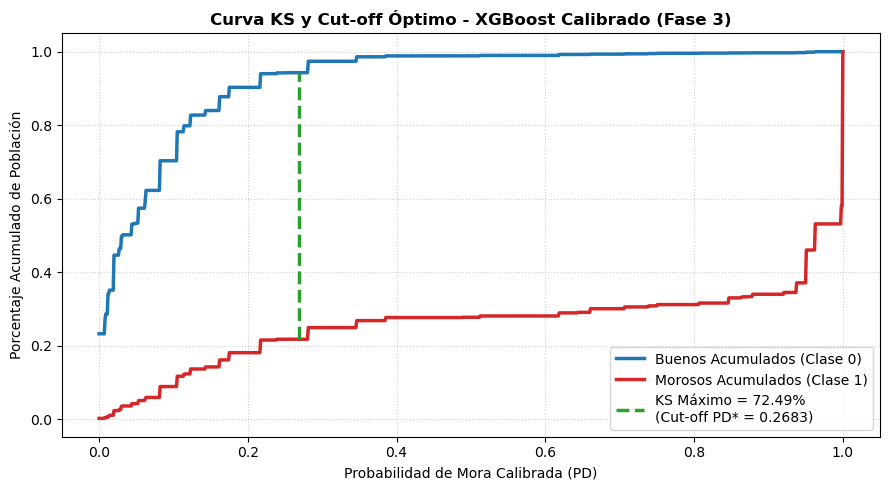

In [18]:
# Política de crédito, Cut-off óptimo y gráfica KS - XGBoost Calibrado

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Obtención de probabilidades calibradas de Default (PD) en Test
pd_test = xgb_calibrado.predict_proba(X_test)[:, 1]

# 2. Separación de la población por clase real
pd_buenos = pd_test[y_test == 0]
pd_morosos = pd_test[y_test == 1]

# 3. Evaluación sobre 1,000 umbrales continuos
umbrales = np.linspace(0, 1, 1000)
acum_buenos = np.array([np.mean(pd_buenos <= u) for u in umbrales])
acum_morosos = np.array([np.mean(pd_morosos <= u) for u in umbrales])

# 4. Cálculo de la distancia máxima (KS Máximo)
distancias_ks = np.abs(acum_buenos - acum_morosos)
idx_optimo = np.argmax(distancias_ks)

cutoff_optimo = umbrales[idx_optimo]
ks_maximo = distancias_ks[idx_optimo] * 100

# 5. Aplicación de la regla de decisión bancaria con el Cut-off óptimo
y_pred_policy = (pd_test > cutoff_optimo).astype(int)
cm = confusion_matrix(y_test, y_pred_policy)

# Tasas operativas bajo esta política
tasa_aprobacion = np.mean(pd_test <= cutoff_optimo) * 100
tasa_rechazo = 100 - tasa_aprobacion

# 6. Reporte de Política de Crédito
print("=" * 60)
print("POLÍTICA DE CRÉDITO Y CUT-OFF ÓPTIMO (XGBOOST CALIBRADO)")
print("=" * 60)
print(f"Cut-off Óptimo (PD*): {cutoff_optimo:.4f} ({cutoff_optimo*100:.2f}%)")
print(f"Estadístico KS Máximo: {ks_maximo:.2f}%")
print("-" * 60)
print(f"Tasa de Aprobación Estimada: {tasa_aprobacion:.2f}% de la cartera")
print(f"Tasa de Rechazo Estimada: {tasa_rechazo:.2f}% de la cartera")
print("-" * 60)
print("Matriz de Confusión Operativa (Absoluta):")
print(pd.DataFrame(cm, index=['Real: Bueno (0)', 'Real: Moroso (1)'], 
                       columns=['Pred: Aprobado', 'Pred: Rechazado']))

# 7. Visualización de la Curva KS con Cut-off de Negocio
plt.figure(figsize=(9, 5))

plt.plot(umbrales, acum_buenos, label='Buenos Acumulados (Clase 0)', color='#1f77b4', lw=2.5)
plt.plot(umbrales, acum_morosos, label='Morosos Acumulados (Clase 1)', color='#d62728', lw=2.5)

# Línea vertical del Cut-off óptimo
plt.vlines(x=cutoff_optimo, ymin=acum_morosos[idx_optimo], ymax=acum_buenos[idx_optimo], 
           color='#2ca02c', linestyle='--', lw=2.5, 
           label=f'KS Máximo = {ks_maximo:.2f}%\n(Cut-off PD* = {cutoff_optimo:.4f})')

plt.title('Curva KS y Cut-off Óptimo - XGBoost Calibrado (Fase 3)', fontsize=12, fontweight='bold')
plt.xlabel('Probabilidad de Mora Calibrada (PD)', fontsize=10)
plt.ylabel('Porcentaje Acumulado de Población', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

#### 9. Interpretabilidad del Modelo y Negocio

#### 10. Conclusiones, Estrategia e Implementación